In [3]:
# ── Setup ──
import os, json, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

DATA_DIR = Path(".").resolve()
POST_DIR = DATA_DIR / "post"
EXPERIMENT_LOG = DATA_DIR / "experiment_log.csv"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [4]:
# ── Load manifest + splits (reused from Week 2) ──
manifest = pd.read_csv(DATA_DIR / "manifest_train_split.csv")
CLASSES = sorted(manifest["damage_label"].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASSES)
print(manifest["model_split"].value_counts())

['destroyed', 'major-damage', 'minor-damage', 'no-damage']
model_split
train    13901
val       3512
test      3458
Name: count, dtype: int64


In [5]:
# ── Damage severity scale (built from CLASSES so it's correct regardless of alphabetical order) ──
DAMAGE_SCALE = {"no-damage": 0, "minor-damage": 1, "major-damage": 2, "destroyed": 3}
SCALE_VALUES = torch.tensor([DAMAGE_SCALE[c] for c in CLASSES], dtype=torch.float32).to(device)

In [6]:
# ── Dataset ──
IMG_SIZE = 128

class SingleImageDataset(Dataset):
    def __init__(self, df, img_dir, base_col, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.base_col = base_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row[self.base_col]).convert("RGB")
        x = self.transform(img)
        y = CLASS_TO_IDX[row["damage_label"]]
        return x, y

# Training transform: light augmentation to help the model generalize
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

# Eval transform: no augmentation, just resize + tensor
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = SingleImageDataset(manifest[manifest.model_split == "train"], POST_DIR, "post_base", train_tfm)
val_ds   = SingleImageDataset(manifest[manifest.model_split == "val"],   POST_DIR, "post_base", eval_tfm)
test_ds  = SingleImageDataset(manifest[manifest.model_split == "test"],  POST_DIR, "post_base", eval_tfm)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 13901 Val: 3512 Test: 3458


In [7]:
# ── Class weights (handles the ~74% no-damage imbalance) ──
train_labels = manifest[manifest.model_split == "train"]["damage_label"].map(CLASS_TO_IDX).values
weights = compute_class_weight("balanced", classes=np.arange(len(CLASSES)), y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(dict(zip(CLASSES, weights.round(2))))

{'destroyed': np.float64(3.05), 'major-damage': np.float64(2.6), 'minor-damage': np.float64(2.43), 'no-damage': np.float64(0.35)}


In [8]:
# ── Model: 4 conv blocks + BatchNorm + Dropout (the version that got macro F1 0.56) ──
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = ImprovedCNN(num_classes=len(CLASSES)).to(device)
print("Device:", device)

Device: mps


In [9]:
# ── Training loop ──
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 25
MODEL_NAME = "improved_cnn_v1"
history = []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)
    history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"epoch {epoch:02d}  train_loss {tr_loss:.3f} acc {tr_acc:.3f}  |  val_loss {val_loss:.3f} acc {val_acc:.3f}  |  lr {optimizer.param_groups[0]['lr']:.5f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), DATA_DIR / f"{MODEL_NAME}_best.pt")

pd.DataFrame(history)

epoch 01  train_loss 1.178 acc 0.467  |  val_loss 1.220 acc 0.404  |  lr 0.00100
epoch 02  train_loss 1.137 acc 0.489  |  val_loss 1.375 acc 0.304  |  lr 0.00100
epoch 03  train_loss 1.096 acc 0.513  |  val_loss 1.334 acc 0.372  |  lr 0.00100
epoch 04  train_loss 1.080 acc 0.518  |  val_loss 1.233 acc 0.534  |  lr 0.00050
epoch 05  train_loss 1.037 acc 0.541  |  val_loss 1.118 acc 0.468  |  lr 0.00050
epoch 06  train_loss 1.022 acc 0.558  |  val_loss 1.086 acc 0.492  |  lr 0.00050
epoch 07  train_loss 0.993 acc 0.581  |  val_loss 0.995 acc 0.515  |  lr 0.00050
epoch 08  train_loss 0.975 acc 0.588  |  val_loss 0.999 acc 0.546  |  lr 0.00050
epoch 09  train_loss 0.968 acc 0.589  |  val_loss 0.993 acc 0.542  |  lr 0.00050
epoch 10  train_loss 0.948 acc 0.600  |  val_loss 0.994 acc 0.574  |  lr 0.00050
epoch 11  train_loss 0.943 acc 0.611  |  val_loss 0.902 acc 0.667  |  lr 0.00050
epoch 12  train_loss 0.930 acc 0.619  |  val_loss 0.937 acc 0.571  |  lr 0.00050
epoch 13  train_loss 0.920 a

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.178045,0.466657,1.220178,0.404328
1,2,1.136887,0.488742,1.374929,0.304100
2,3,1.096447,0.513200,1.334082,0.372437
3,4,1.080406,0.517733,1.233395,0.533599
4,5,1.037333,0.540968,1.117500,0.468109
5,6,1.022471,0.557730,1.086091,0.492312
6,7,0.992982,0.580750,0.995069,0.515376
7,8,0.975035,0.587656,0.998558,0.546412
8,9,0.967990,0.588878,0.992612,0.542141
9,10,0.947883,0.600101,0.993823,0.574032



VAL SET
              precision    recall  f1-score   support

   destroyed       0.63      0.58      0.60       393
major-damage       0.32      0.55      0.40       207
minor-damage       0.31      0.60      0.41       212
   no-damage       0.91      0.81      0.86      2700

    accuracy                           0.75      3512
   macro avg       0.54      0.63      0.57      3512
weighted avg       0.81      0.75      0.77      3512



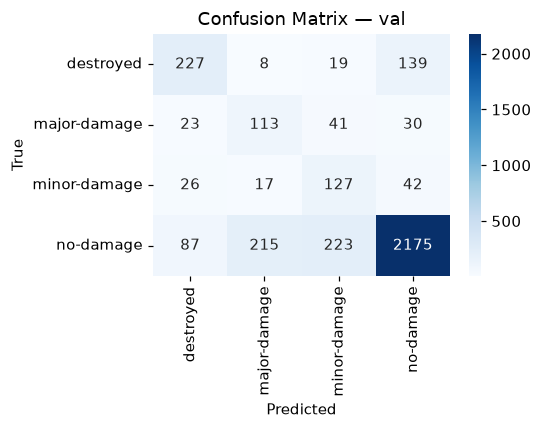


TEST SET
              precision    recall  f1-score   support

   destroyed       0.28      0.67      0.39       165
major-damage       0.22      0.34      0.27       271
minor-damage       0.28      0.44      0.34       273
   no-damage       0.91      0.73      0.81      2749

    accuracy                           0.68      3458
   macro avg       0.42      0.54      0.45      3458
weighted avg       0.78      0.68      0.71      3458



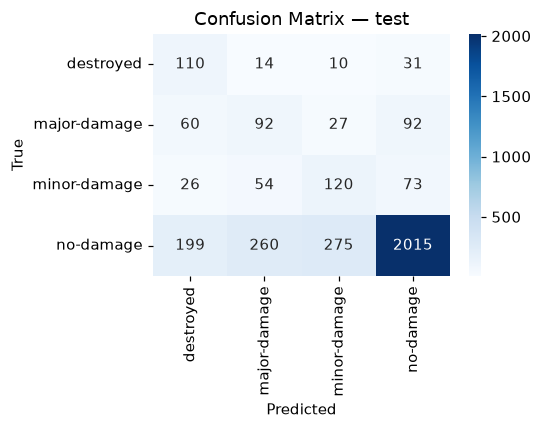

In [10]:
# ── Evaluate on val + test, with classification report AND confusion matrix ──
model.load_state_dict(torch.load(DATA_DIR / f"{MODEL_NAME}_best.pt"))
model.eval()

def evaluate(loader, split_name):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    print(f"\n{split_name.upper()} SET")
    report = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return report

val_report = evaluate(val_loader, "val")
test_report = evaluate(test_loader, "test")

In [11]:
# ── Damage severity scale check (soft score should increase monotonically with true severity) ──
@torch.no_grad()
def score_images(loader):
    model.eval()
    scores = []
    for x, _ in loader:
        probs = F.softmax(model(x.to(device)), dim=1)
        expected = (probs * SCALE_VALUES).sum(dim=1)
        scores.extend(expected.cpu().numpy())
    return np.array(scores)

true_severity = manifest.loc[manifest.model_split == "test", "damage_label"].map(DAMAGE_SCALE).values
test_scores = score_images(test_loader)

compare_df = pd.DataFrame({"true_severity": true_severity, "predicted_score": test_scores})
correlation = compare_df.corr().iloc[0, 1]
print("Correlation:", round(correlation, 3))
print(compare_df.groupby("true_severity")["predicted_score"].mean())

Correlation: 0.444
true_severity
0    0.670522
1    1.185752
2    1.347327
3    2.080932
Name: predicted_score, dtype: float32


In [12]:
# ── Experiment tracking: log this run to a CSV so results are comparable across the team ──
def log_experiment(model_name, epochs_run, best_val_acc, test_report, correlation, notes=""):
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model_name": model_name,
        "epochs": epochs_run,
        "best_val_acc": round(best_val_acc, 4),
        "test_accuracy": round(test_report["accuracy"], 4),
        "test_macro_f1": round(test_report["macro avg"]["f1-score"], 4),
        "test_weighted_f1": round(test_report["weighted avg"]["f1-score"], 4),
        "severity_correlation": round(correlation, 4),
        "notes": notes,
    }
    # add per-class F1 too
    for c in CLASSES:
        row[f"f1_{c}"] = round(test_report[c]["f1-score"], 4)

    log_df = pd.DataFrame([row])
    if EXPERIMENT_LOG.exists():
        log_df.to_csv(EXPERIMENT_LOG, mode="a", header=False, index=False)
    else:
        log_df.to_csv(EXPERIMENT_LOG, index=False)
    print("Logged experiment:", row)

log_experiment(
    model_name=MODEL_NAME,
    epochs_run=EPOCHS,
    best_val_acc=best_val_acc,
    test_report=test_report,
    correlation=correlation,
    notes="4 conv blocks + BatchNorm + Dropout, train-time augmentation, ReduceLROnPlateau scheduler, post-images only"
)

Logged experiment: {'timestamp': '2026-08-26T17:04:41', 'model_name': 'improved_cnn_v1', 'epochs': 25, 'best_val_acc': 0.7523, 'test_accuracy': 0.6758, 'test_macro_f1': 0.453, 'test_weighted_f1': 0.7124, 'severity_correlation': np.float64(0.4442), 'notes': '4 conv blocks + BatchNorm + Dropout, train-time augmentation, ReduceLROnPlateau scheduler, post-images only', 'f1_destroyed': 0.3929, 'f1_major-damage': 0.2663, 'f1_minor-damage': 0.3404, 'f1_no-damage': 0.8125}


In [13]:
# ── View experiment log so far ──
pd.read_csv(EXPERIMENT_LOG)

,timestamp,model_name,epochs,best_val_acc,test_accuracy,test_macro_f1,test_weighted_f1,severity_correlation,notes,f1_destroyed,f1_major-damage,f1_minor-damage,f1_no-damage
0,2026-08-26T17:04:41,improved_cnn_v1,25,0.7523,0.6758,0.453,0.7124,0.4442,"4 conv blocks + BatchNorm + Dropout, train-tim...",0.3929,0.2663,0.3404,0.8125


### Week 3 Summary — Baseline Complete

**Settings**
- Dataset: `manifest_train_split.csv` (regenerated 2026-08-26), post-disaster images only, scene-based split — train 13901 / val 3512 / test 3458
- Image size 128×128, batch size 32, class-weighted `CrossEntropyLoss`
- Model: `ImprovedCNN` (4 conv blocks + BatchNorm + Dropout), train-time augmentation, Adam (lr=1e-3) + `ReduceLROnPlateau`
- 25 epochs, best checkpoint at epoch 24 (val_acc 0.752) → saved to `improved_cnn_v1_best.pt`
- Runs are tracked in `experiment_log.csv` for easy comparison across models/teammates

**Test set results**: accuracy 0.676, macro F1 **0.453**, weighted F1 0.712
- Per-class F1: destroyed 0.39, major-damage 0.27, minor-damage 0.34, no-damage 0.81

**Numeric damage scale is monotonic**: mean predicted severity climbs from 0.67 (no-damage) → 1.19 (minor) → 1.35 (major) → 2.08 (destroyed). Correlation with true severity: 0.44.

Scope note: the model only looks at post-disaster images by design — damage level is predicted directly from a single post image, no pre/post comparison involved.


### Week 3: Baseline Model

The goal is a CNN that looks at a single post-disaster image of a building and predicts its damage level (no-damage, minor-damage, major-damage, destroyed). The model only uses post-disaster images — damage is classified directly from the post image rather than by comparing it to a pre-disaster image.

Early iteration: a simple 2-layer CNN trained for 20 epochs reached macro F1 0.40, but its continuous damage score wasn't monotonic — minor-damage buildings scored higher on average than major-damage or destroyed ones, which contradicts the idea that a lower score should mean less damage. This was fixed by moving to a deeper 4-conv-block CNN with BatchNorm + Dropout, train-time augmentation (flips, rotation, color jitter), and a `ReduceLROnPlateau` learning-rate scheduler — this is the `ImprovedCNN` used below.

This run uses the regenerated train/val/test split (13901 / 3512 / 3458 images, scene-based to avoid leakage), 128x128 images, and a class-weighted loss since no-damage makes up ~74% of the data. `ImprovedCNN` trained for 25 epochs; the best checkpoint (epoch 24, val_acc 0.752) is saved to `improved_cnn_v1_best.pt`, and the run is logged to `experiment_log.csv` for comparing against teammates' runs.

On the test set: accuracy 0.676, macro F1 0.453, weighted F1 0.712. The damage score is still monotonic — 0.67, 1.19, 1.35, 2.08 from no-damage to destroyed — with a 0.44 correlation to true severity.

Macro F1 is lower here (0.45) than the 0.56 seen on the earlier, smaller split. The monotonic trend and per-class ordering held up, so this looks more like the larger/regenerated split being harder than a regression in the model itself — worth a quick sanity check (e.g. comparing class balance) before drawing conclusions.
